# XAI Method Feature Importance Consistency

This notebook investigates how the **choice of explainability method** affects the interpretation of feature importance — comparing three XAI methods **within** the same model and preprocessing strategy.

For every combination of model × strategy, the three XAI methods are compared against each other:

| Model | Method A | Method B | Method C |
|---|---|---|---|
| Logistic Regression | SHAP | Permutation | Coefficient |
| Random Forest | SHAP | Permutation | Mean Decrease Impurity |
| XGBoost | SHAP | Permutation | XGBoost Gain |
| Decision Tree | SHAP | Permutation | Gini Importance |

Comparisons are always **same model × same strategy, different XAI method** — never cross-model.

**Methods used:**
- Top-10 overlap — how many of the top 10 features are shared between two XAI methods
- Spearman rank correlation — how similar the full feature rankings are (rank-based, so importance scale does not matter)
- Jaccard similarity — set-based overlap of the top-10 feature lists

> **Note on importance scores:** Each XAI method uses a different scale (mean |SHAP|, ROC AUC drop, coefficients, impurity/gain). Importance values are therefore **never compared directly** — only ranks and top-N membership are used.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from itertools import combinations

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120,
})

os.makedirs("../results/figures/xai_method_consistency/", exist_ok=True)

MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":        "#2a8a5e",
    "XGBoost":              "#a04e0a",
    "Decision Tree":        "#7a3090",
}

# Model-specific method label per model
MODEL_SPECIFIC_METHOD = {
    "Logistic Regression": "Coefficient",
    "Random Forest":        "Mean Decrease Impurity",
    "XGBoost":              "XGBoost Gain",
    "Decision Tree":        "Gini Importance",
}

# XAI method display order and colours for plots
METHOD_COLORS = {
    "SHAP":       "#4a7fa5",
    "Permutation": "#e07b39",
    "Specific":    "#5b9e6b",   # placeholder; label replaced per model in plots
}

MODELS     = list(MODEL_COLORS.keys())
STRATEGIES = ["SMOTE", "Undersampling"]
TOP_N      = 10

## Loading Feature Importance Data

All feature importance CSV files are loaded. All three XAI methods are retained. The data is grouped by `Model × Strategy` so that every comparison is strictly within the same trained model.

In [2]:
files = glob.glob("../results/features/*_feature_importance.csv")

if not files:
    raise FileNotFoundError("No feature importance files found. Run all model notebooks first.")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Normalise method names: map model-specific labels to a generic "Specific" key
# so downstream code can reference them uniformly, while keeping the original
# label in a separate column for display purposes.
df["Method_Original"] = df["Method"]
specific_labels = set(MODEL_SPECIFIC_METHOD.values())
df["Method_Key"] = df["Method"].apply(
    lambda m: "Specific" if m in specific_labels else m
)

print("Models:     ", df["Model"].unique())
print("Strategies: ", df["Strategy"].unique())
print("Methods:    ", df["Method_Original"].unique())
print("Total rows: ", len(df))

Models:      ['Logistic Regression' 'Decision Tree' 'XGBoost' 'Random Forest']
Strategies:  ['Undersampling' 'SMOTE']
Methods:     ['SHAP' 'Permutation' 'Coefficient' 'Gini Importance' 'XGBoost Gain'
 'Mean Decrease Impurity']
Total rows:  864


## Helper Functions

The same three consistency metrics as in notebooks 05 and 06, re-parameterised to compare **XAI methods** instead of models or strategies.

> Because importance scores are on different scales across methods, **only ranks and top-N membership are used** — importance values are never compared directly.

In [3]:
def get_top_n(df, model, strategy, method_key, n=TOP_N):
    """Return the top-N feature names for a given model, strategy and XAI method."""
    subset = df[
        (df["Model"]       == model) &
        (df["Strategy"]    == strategy) &
        (df["Method_Key"]  == method_key)
    ]
    return set(subset.nsmallest(n, "Rank")["Feature"].tolist())


def get_full_ranking(df, model, strategy, method_key):
    """Return a Series of rank values indexed by feature name."""
    subset = df[
        (df["Model"]       == model) &
        (df["Strategy"]    == strategy) &
        (df["Method_Key"]  == method_key)
    ]
    return subset.set_index("Feature")["Rank"].sort_values()


def top_n_overlap(df, model, strategy, method_a, method_b, n=TOP_N):
    """Number of shared features in the top N between two XAI methods."""
    top_a = get_top_n(df, model, strategy, method_a, n)
    top_b = get_top_n(df, model, strategy, method_b, n)
    return len(top_a & top_b)


def spearman_correlation(df, model, strategy, method_a, method_b):
    """Spearman rank correlation of full feature rankings between two XAI methods."""
    rank_a = get_full_ranking(df, model, strategy, method_a)
    rank_b = get_full_ranking(df, model, strategy, method_b)
    common = rank_a.index.intersection(rank_b.index)
    if len(common) < 2:
        return np.nan
    corr, _ = spearmanr(rank_a[common], rank_b[common])
    return round(corr, 4)


def jaccard_similarity(df, model, strategy, method_a, method_b, n=TOP_N):
    """Jaccard similarity of top-N feature sets between two XAI methods."""
    top_a = get_top_n(df, model, strategy, method_a, n)
    top_b = get_top_n(df, model, strategy, method_b, n)
    if not top_a | top_b:
        return 0.0
    return round(len(top_a & top_b) / len(top_a | top_b), 4)


def build_method_matrix(df, model, strategy, metric_fn):
    """Build a 3×3 symmetric matrix of pairwise XAI method scores."""
    methods = ["SHAP", "Permutation", "Specific"]
    mat = pd.DataFrame(np.nan, index=methods, columns=methods)

    for m in methods:
        if metric_fn == spearman_correlation:
            mat.loc[m, m] = 1.0
        elif metric_fn == jaccard_similarity:
            mat.loc[m, m] = 1.0
        else:  # top_n_overlap
            mat.loc[m, m] = float(TOP_N)

    for a, b in combinations(methods, 2):
        val = metric_fn(df, model, strategy, a, b)
        mat.loc[a, b] = val
        mat.loc[b, a] = val

    # Replace generic "Specific" label with the model-specific display name
    specific_label = MODEL_SPECIFIC_METHOD.get(model, "Model-Specific")
    mat.index   = [specific_label if m == "Specific" else m for m in mat.index]
    mat.columns = [specific_label if m == "Specific" else m for m in mat.columns]
    return mat


def compute_pairwise_summary(df, n=TOP_N):
    """Compute all pairwise XAI method metrics for every Model × Strategy combination."""
    pairs = [("SHAP", "Permutation"), ("SHAP", "Specific"), ("Permutation", "Specific")]
    rows = []
    for model in MODELS:
        for strategy in STRATEGIES:
            for ma, mb in pairs:
                # Check data availability
                has_a = not df[
                    (df["Model"] == model) &
                    (df["Strategy"] == strategy) &
                    (df["Method_Key"] == ma)
                ].empty
                has_b = not df[
                    (df["Model"] == model) &
                    (df["Strategy"] == strategy) &
                    (df["Method_Key"] == mb)
                ].empty
                if not (has_a and has_b):
                    continue

                specific_name = MODEL_SPECIFIC_METHOD.get(model, "Model-Specific")
                label_a = specific_name if ma == "Specific" else ma
                label_b = specific_name if mb == "Specific" else mb

                rows.append({
                    "Model":              model,
                    "Strategy":           strategy,
                    "Method A":           label_a,
                    "Method B":           label_b,
                    "Top-N Overlap":      top_n_overlap(df, model, strategy, ma, mb, n),
                    "Spearman ρ":         spearman_correlation(df, model, strategy, ma, mb),
                    "Jaccard Similarity": jaccard_similarity(df, model, strategy, ma, mb, n),
                })
    return pd.DataFrame(rows)

---
# Section 1 — Side-by-Side Top-10 Rankings per XAI Method

For each model × strategy combination, the top 10 features are shown side-by-side across all three XAI methods. Features that appear in **all three** top-10 lists are highlighted in the model's colour; features unique to one method appear in grey.

Note: bars within each panel use that method's own importance scale — values across panels are **not** directly comparable.

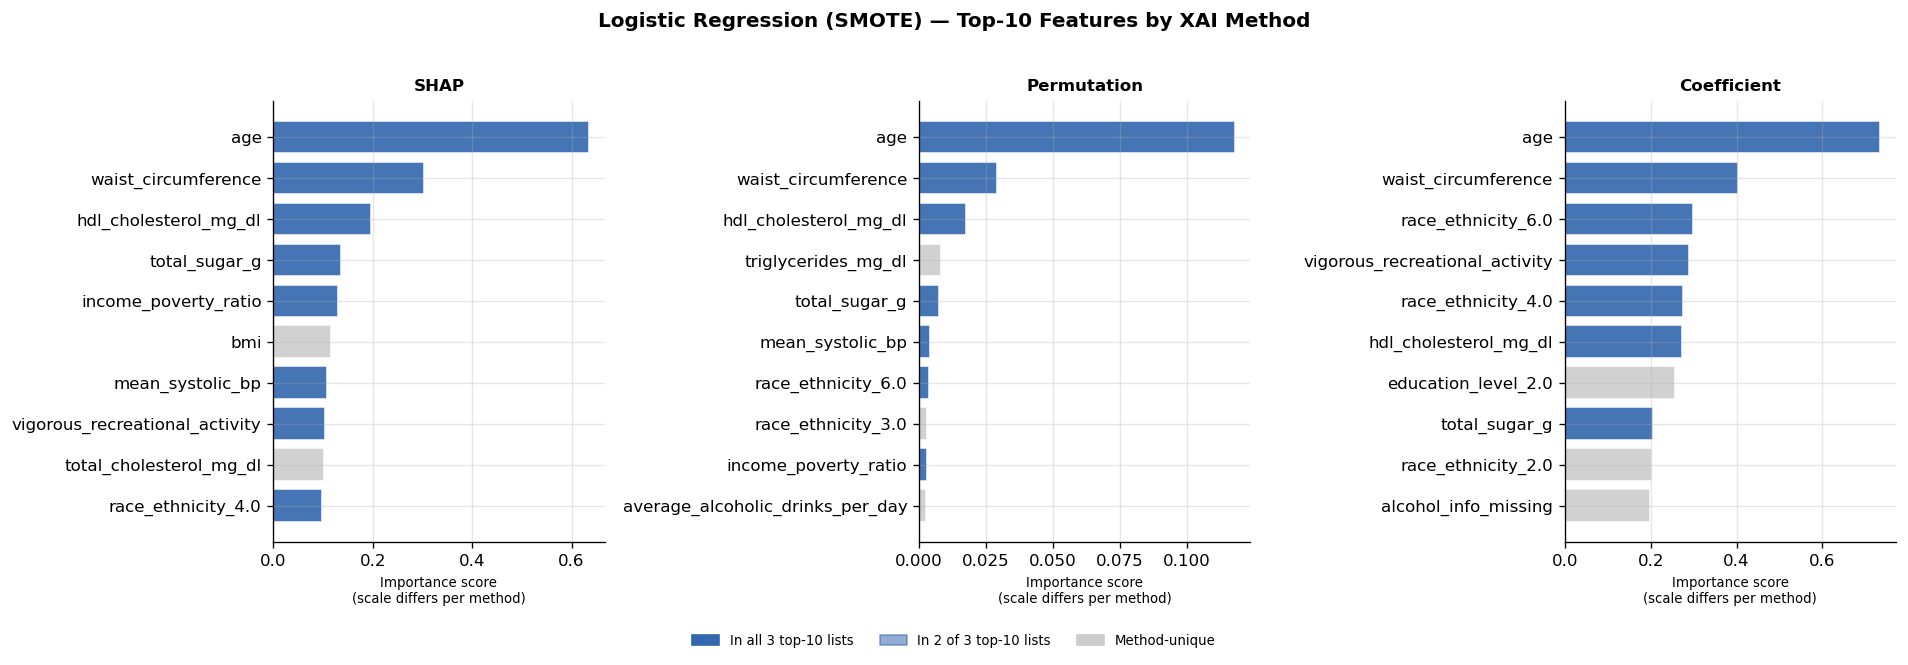

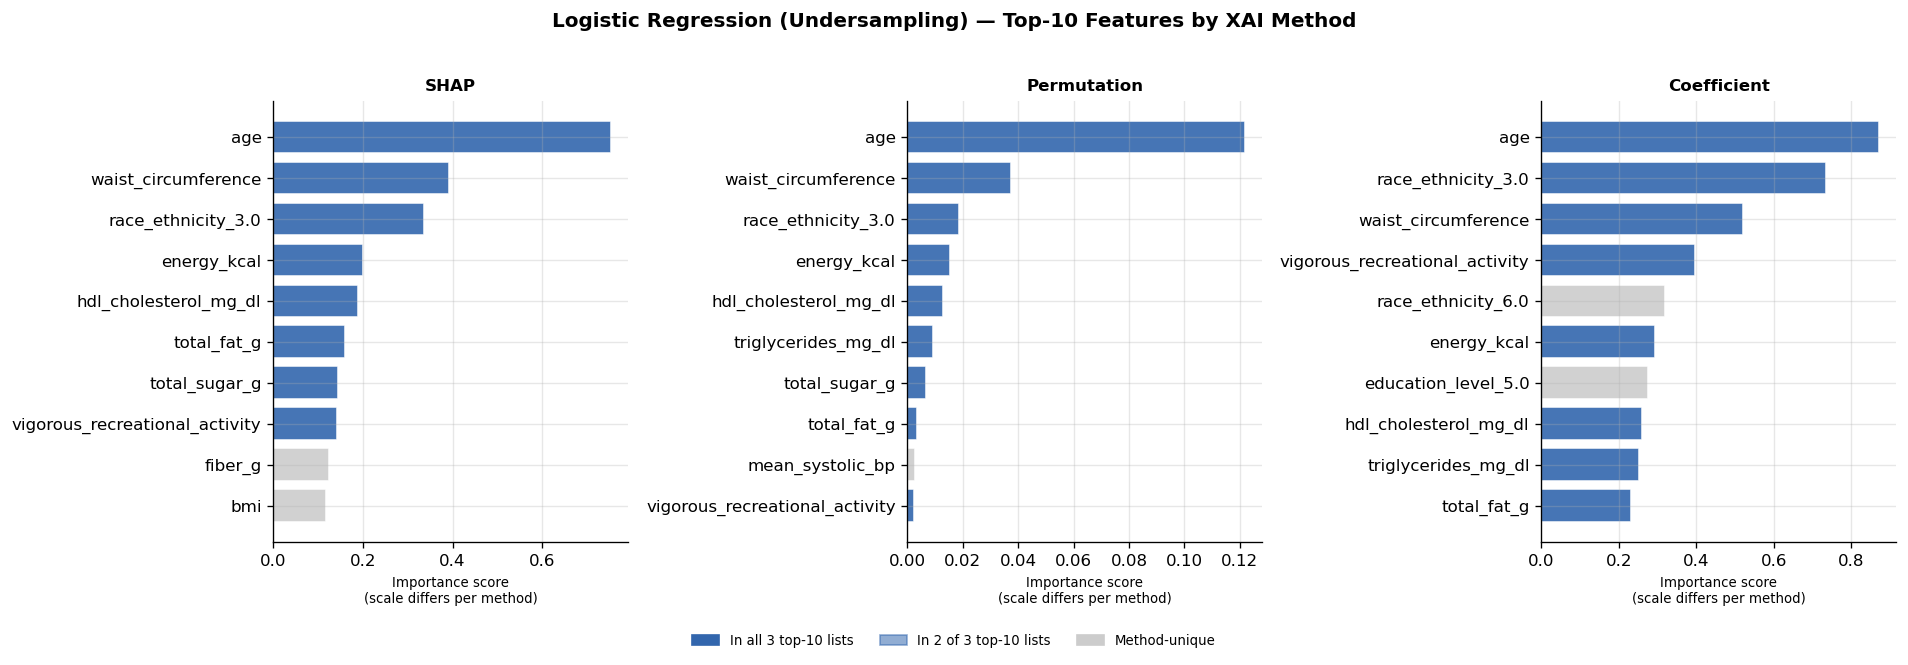

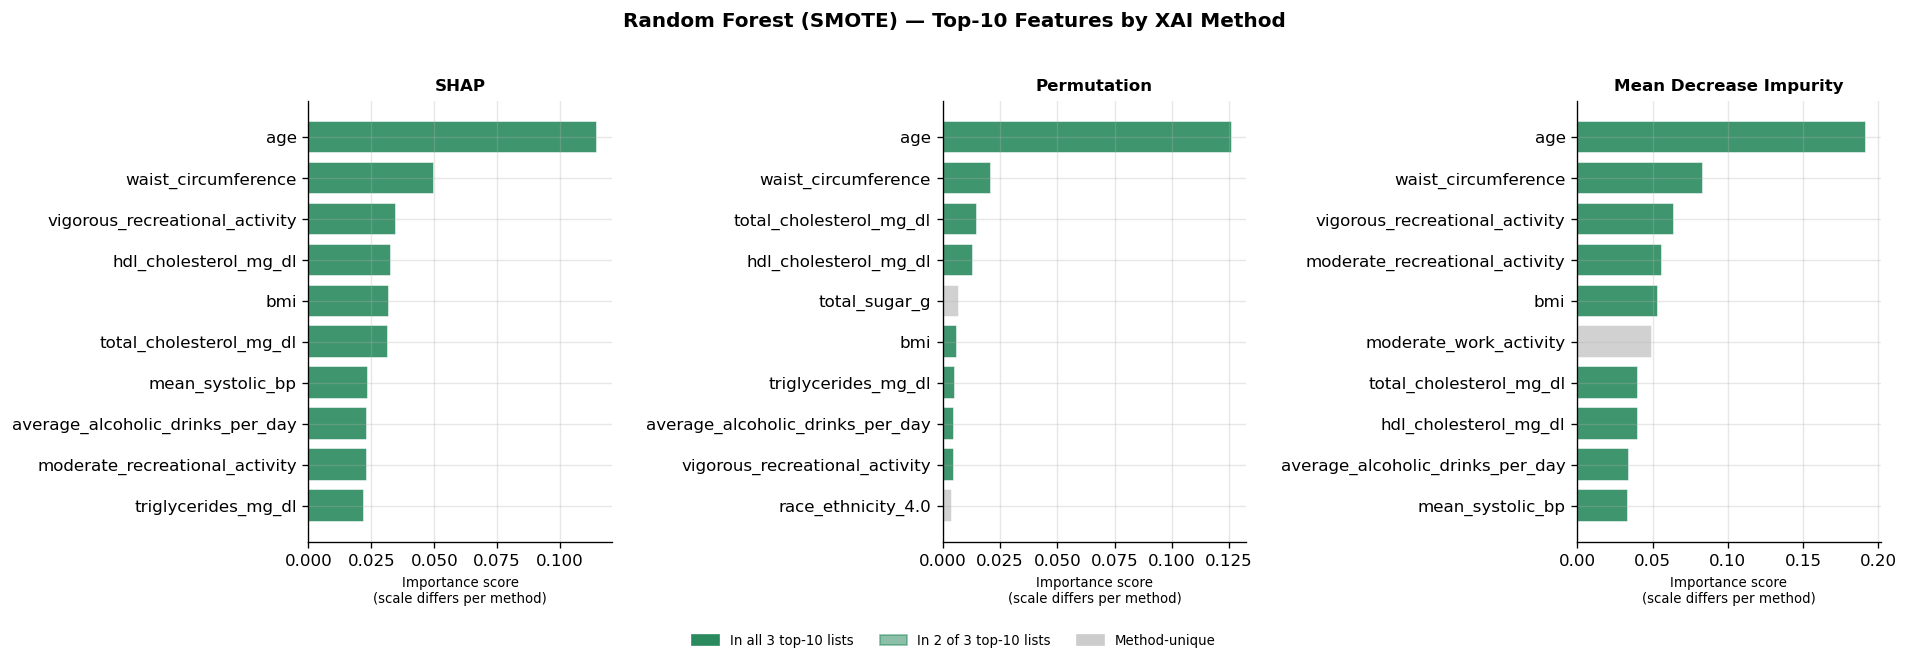

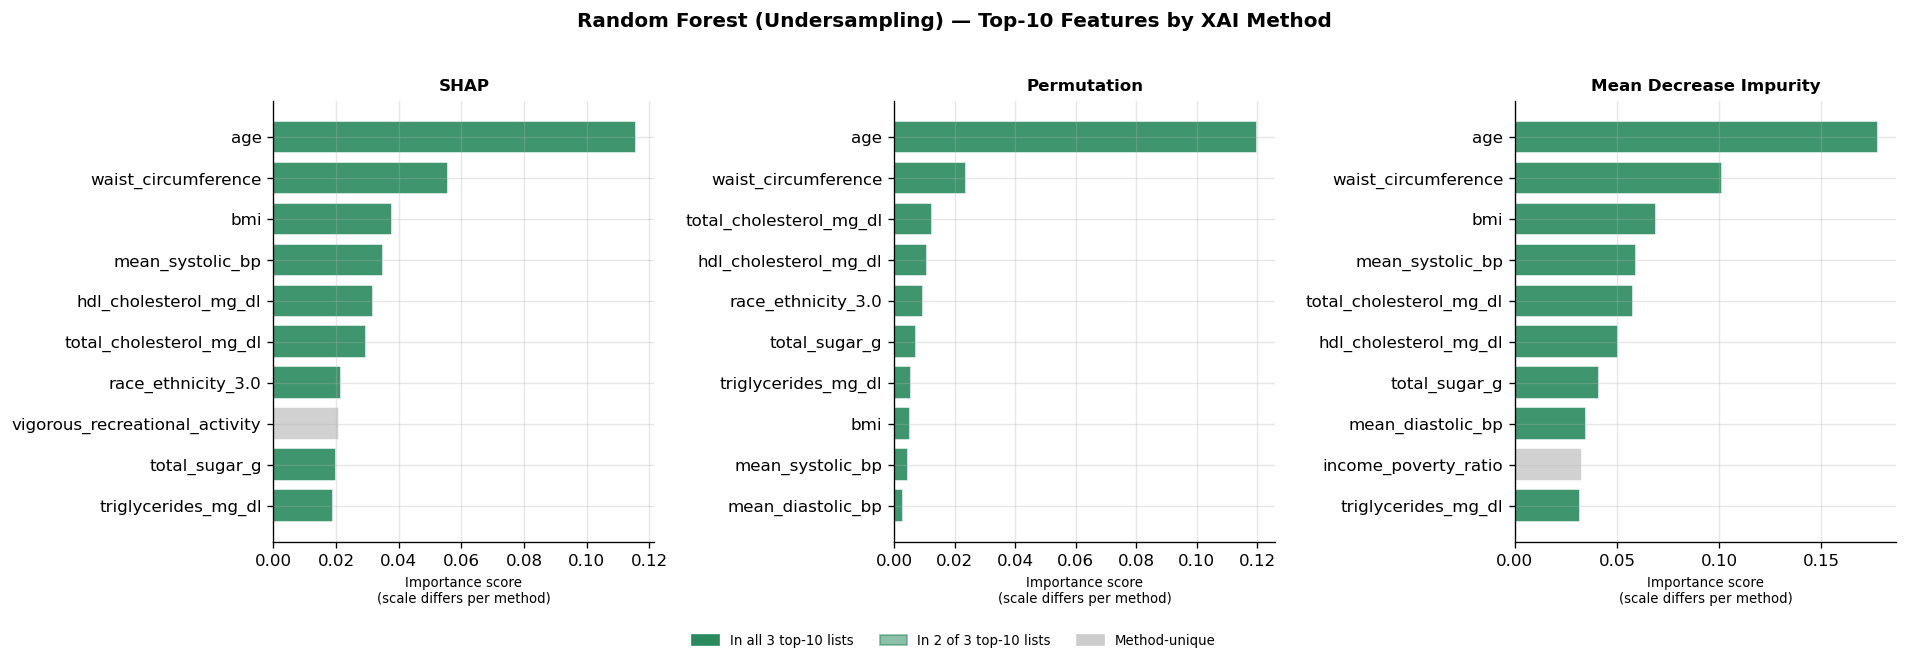

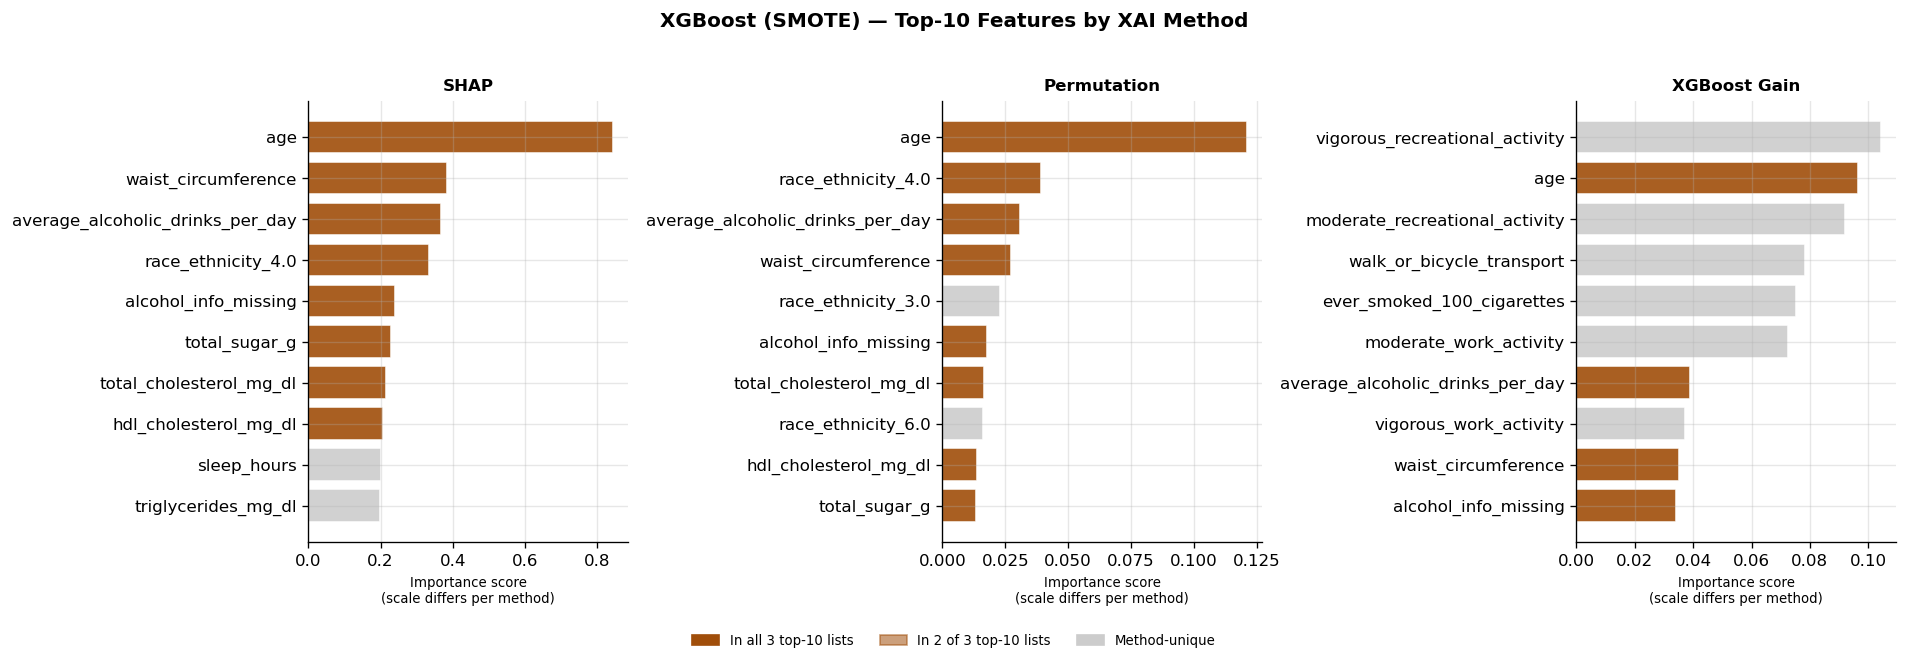

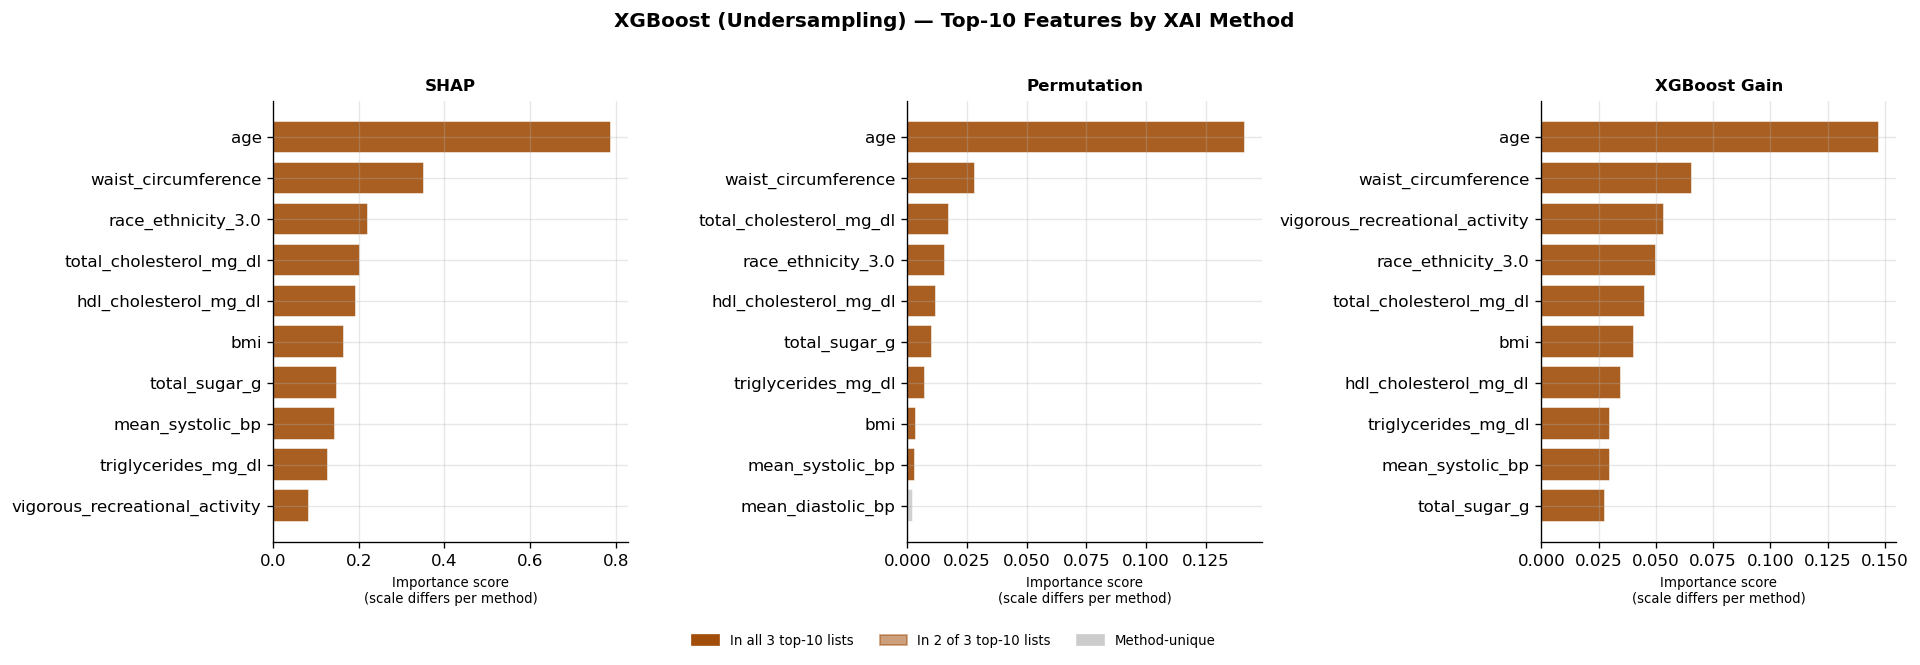

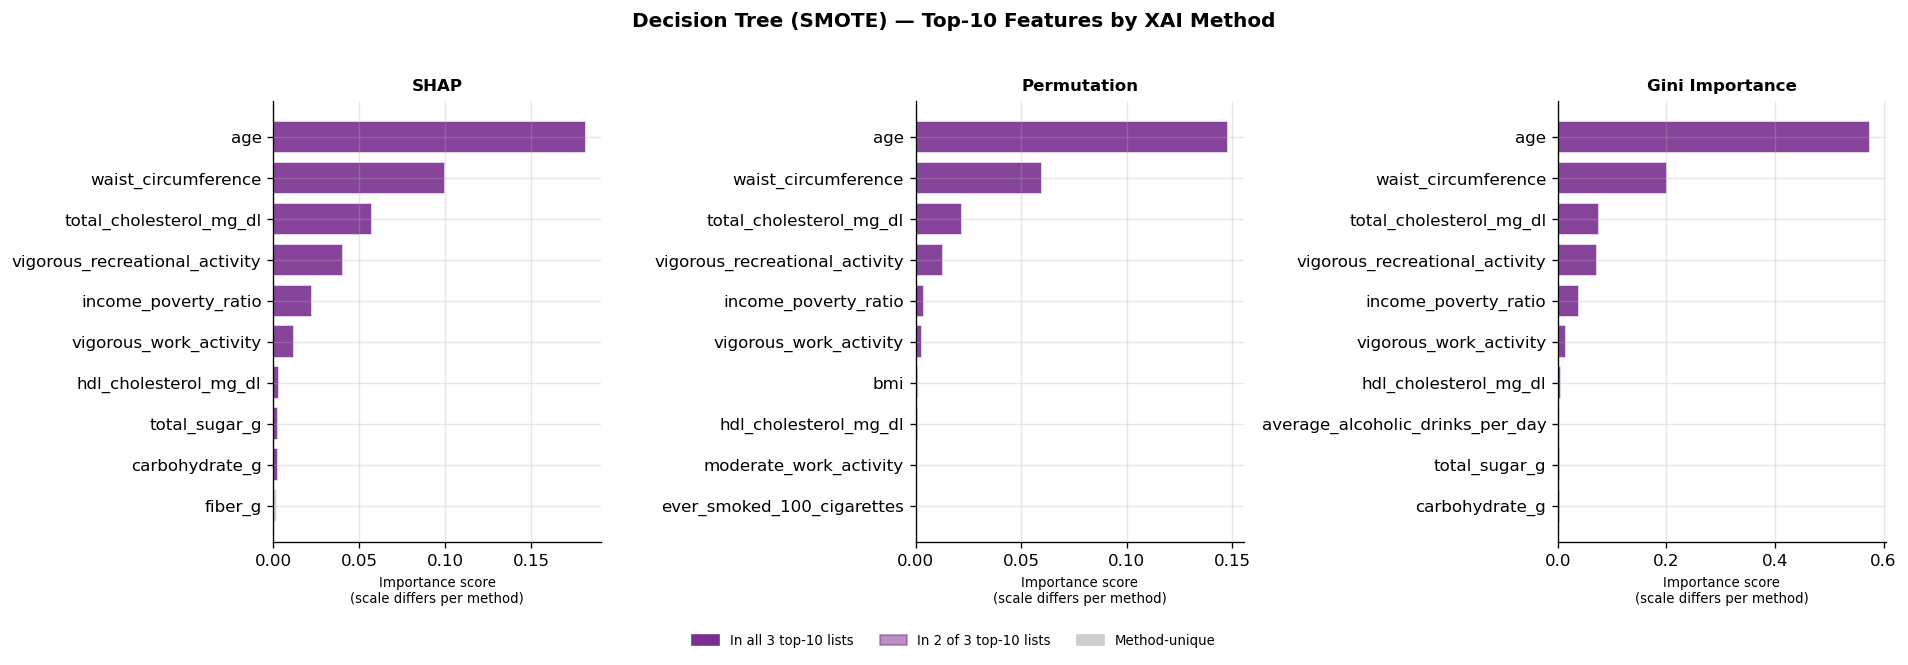

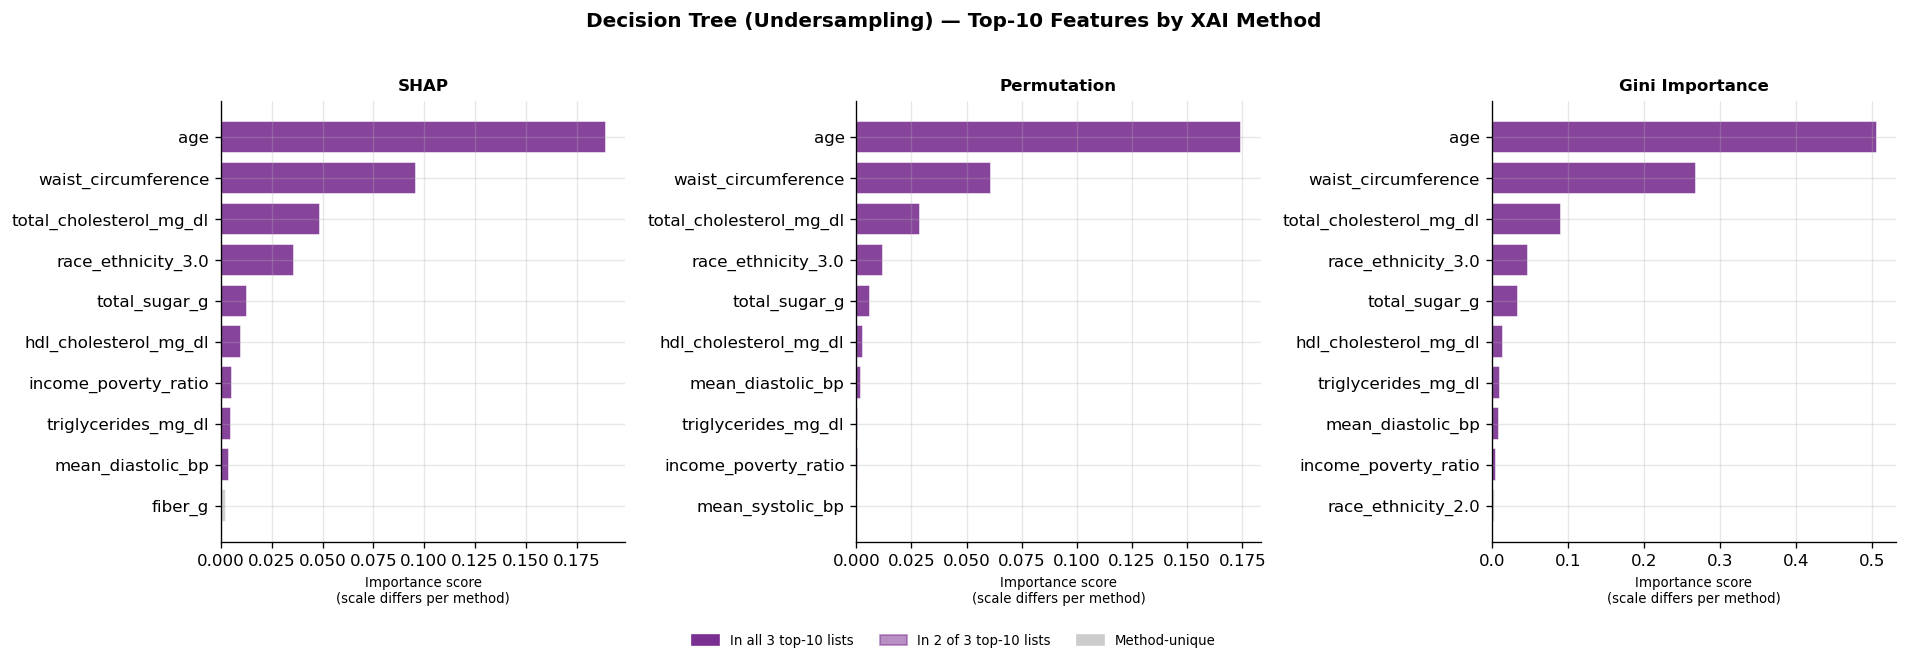

In [4]:
for model in MODELS:
    specific_label = MODEL_SPECIFIC_METHOD[model]
    method_keys    = ["SHAP", "Permutation", "Specific"]
    method_labels  = ["SHAP", "Permutation", specific_label]
    color          = MODEL_COLORS[model]

    for strategy in STRATEGIES:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # Compute the consensus (features in all 3 top-10 sets)
        tops = [get_top_n(df, model, strategy, mk) for mk in method_keys]
        consensus = tops[0] & tops[1] & tops[2]
        any_two   = (tops[0] & tops[1]) | (tops[0] & tops[2]) | (tops[1] & tops[2])

        for ax, mk, label in zip(axes, method_keys, method_labels):
            subset = df[
                (df["Model"]      == model) &
                (df["Strategy"]   == strategy) &
                (df["Method_Key"] == mk)
            ].nsmallest(TOP_N, "Rank")

            if subset.empty:
                ax.set_title(f"{label}\n(no data)", fontsize=10)
                ax.axis("off")
                continue

            subset = subset.sort_values("Importance", ascending=True)

            # Colour coding: consensus = full model colour, in-2 = lighter, unique = grey
            def bar_color(feat):
                if feat in consensus:  return color
                if feat in any_two:    return color + "88"  # semi-transparent
                return "#cccccc"

            bc = [bar_color(f) for f in subset["Feature"]]
            ax.barh(subset["Feature"], subset["Importance"],
                    color=bc, edgecolor="white", alpha=0.9)
            ax.set_title(label, fontsize=10, fontweight="bold")
            ax.set_xlabel("Importance score\n(scale differs per method)", fontsize=8)

        # Legend
        p1 = mpatches.Patch(color=color,     label="In all 3 top-10 lists")
        p2 = mpatches.Patch(color=color+"88", label="In 2 of 3 top-10 lists")
        p3 = mpatches.Patch(color="#cccccc", label="Method-unique")
        fig.legend(handles=[p1, p2, p3], loc="lower center", ncol=3,
                   fontsize=8, bbox_to_anchor=(0.5, -0.06), frameon=False)

        fig.suptitle(
            f"{model} ({strategy}) — Top-{TOP_N} Features by XAI Method",
            fontsize=12, fontweight="bold", y=1.02
        )
        plt.tight_layout()

        safe_model    = model.lower().replace(" ", "_")
        safe_strategy = strategy.lower()
        plt.savefig(
            f"../results/figures/xai_method_consistency/{safe_model}_{safe_strategy}_top10.png",
            bbox_inches="tight"
        )
        plt.show()
        print()

---
# Section 2 — Pairwise Metric Heatmaps per Model × Strategy

For each model × strategy combination, three 3×3 heatmaps show the pairwise consistency between XAI methods:
- **Top-10 overlap** (0–10)
- **Spearman ρ** (−1 to 1, full ranking)
- **Jaccard similarity** (0–1)

A high score in all three panels means the two XAI methods lead to the same interpretation, regardless of their different importance scales.

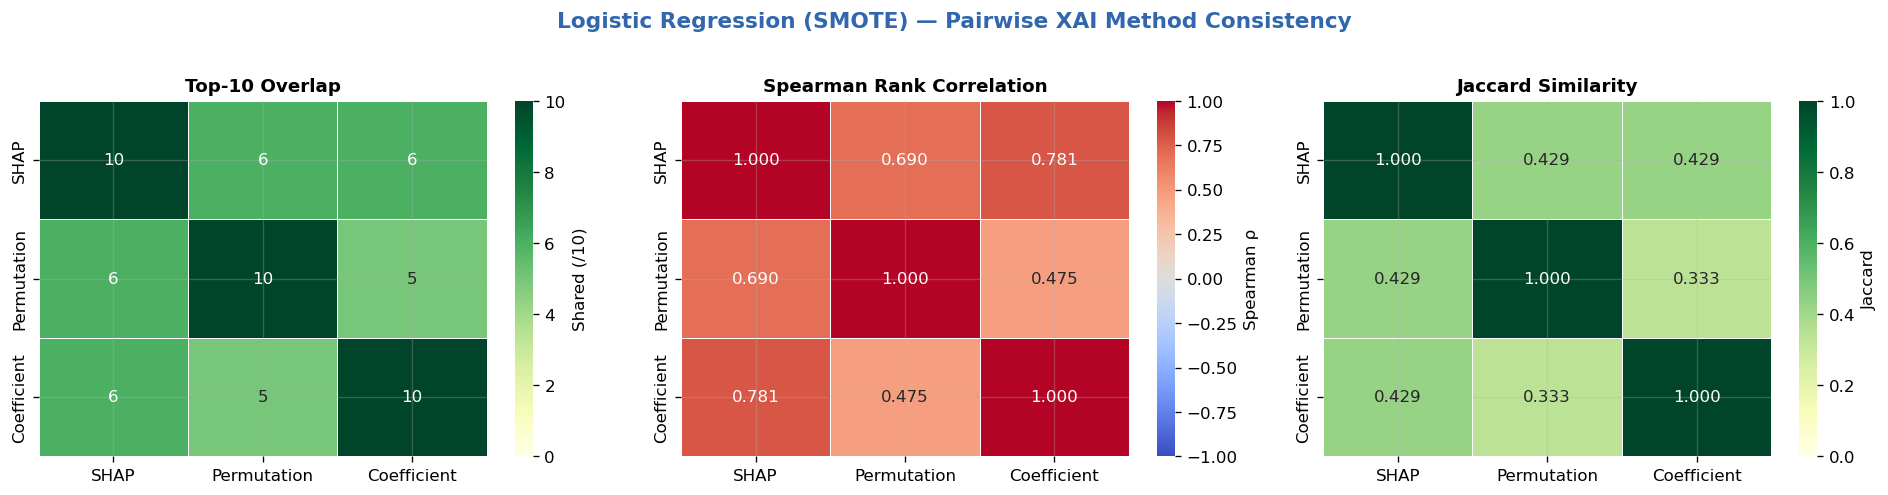

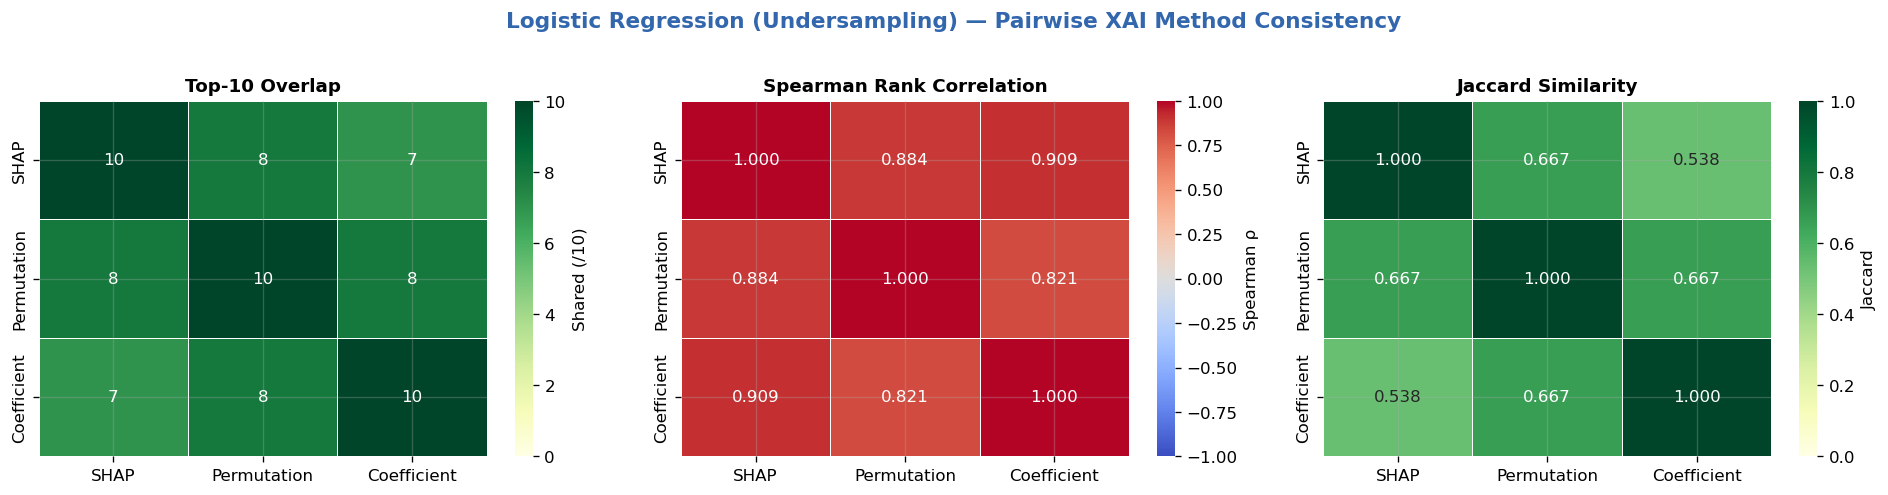

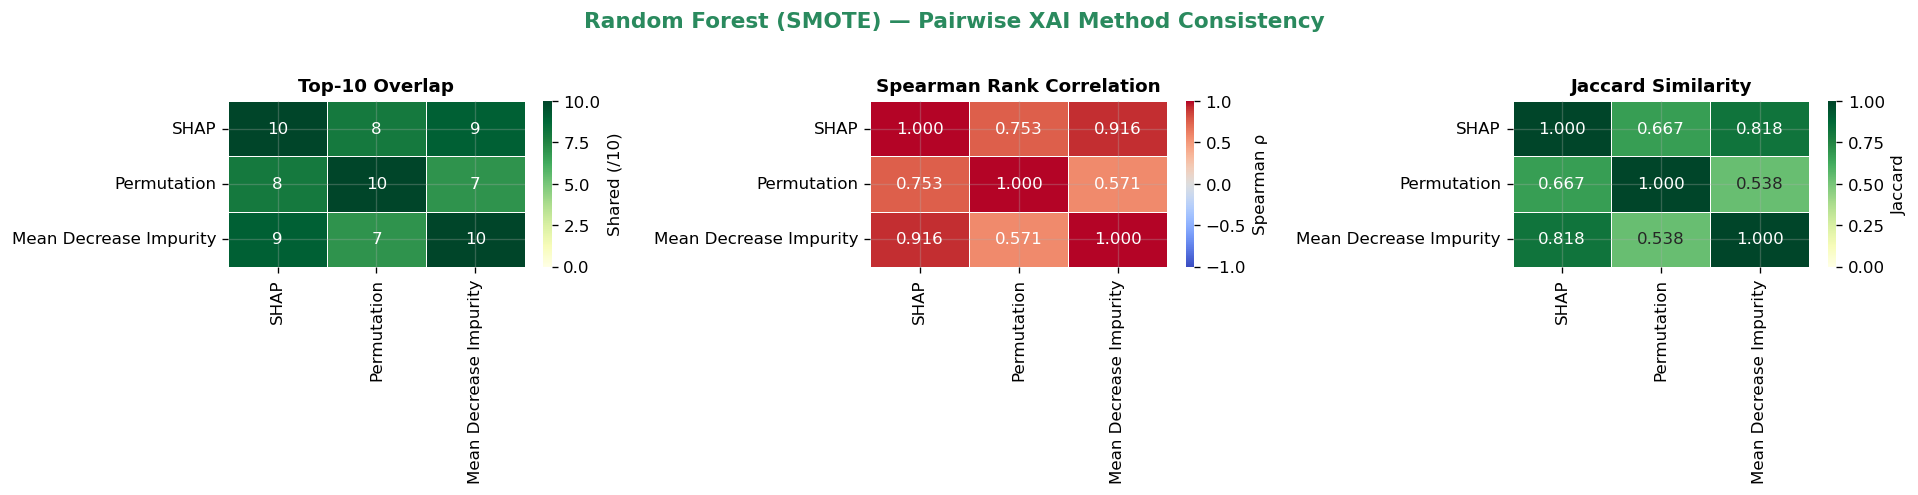

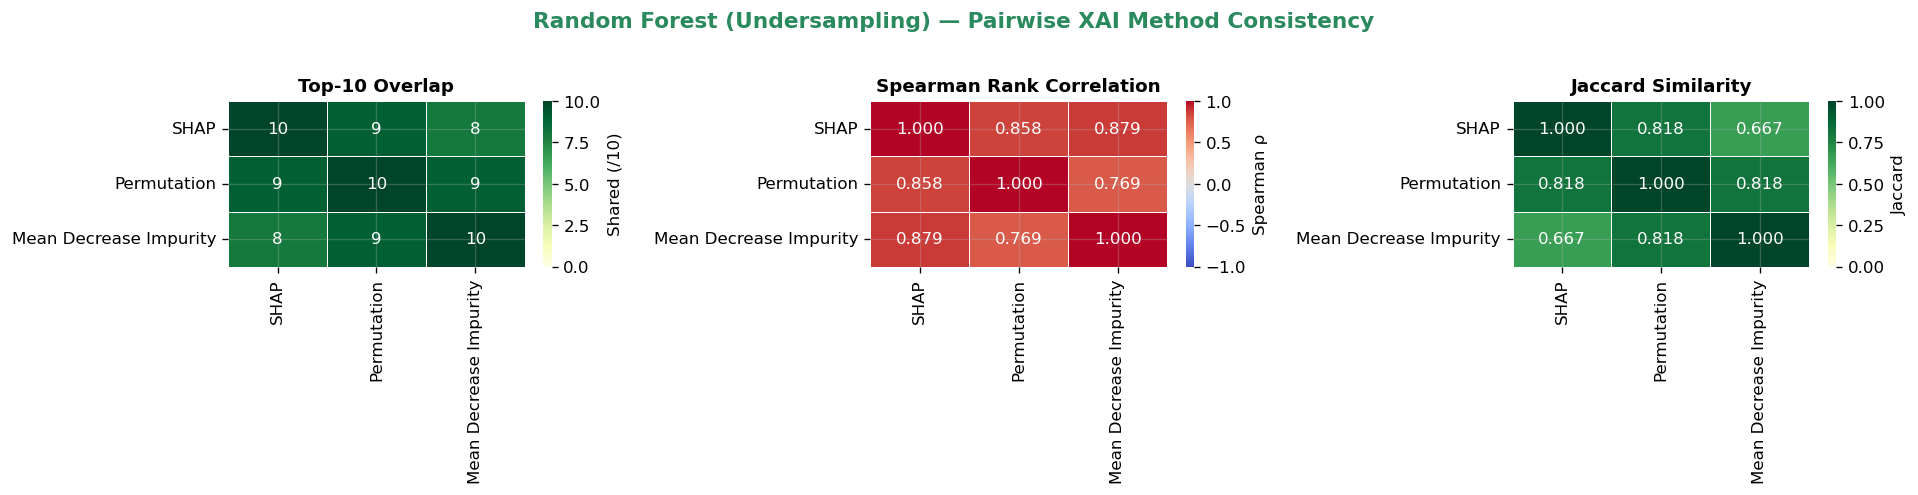

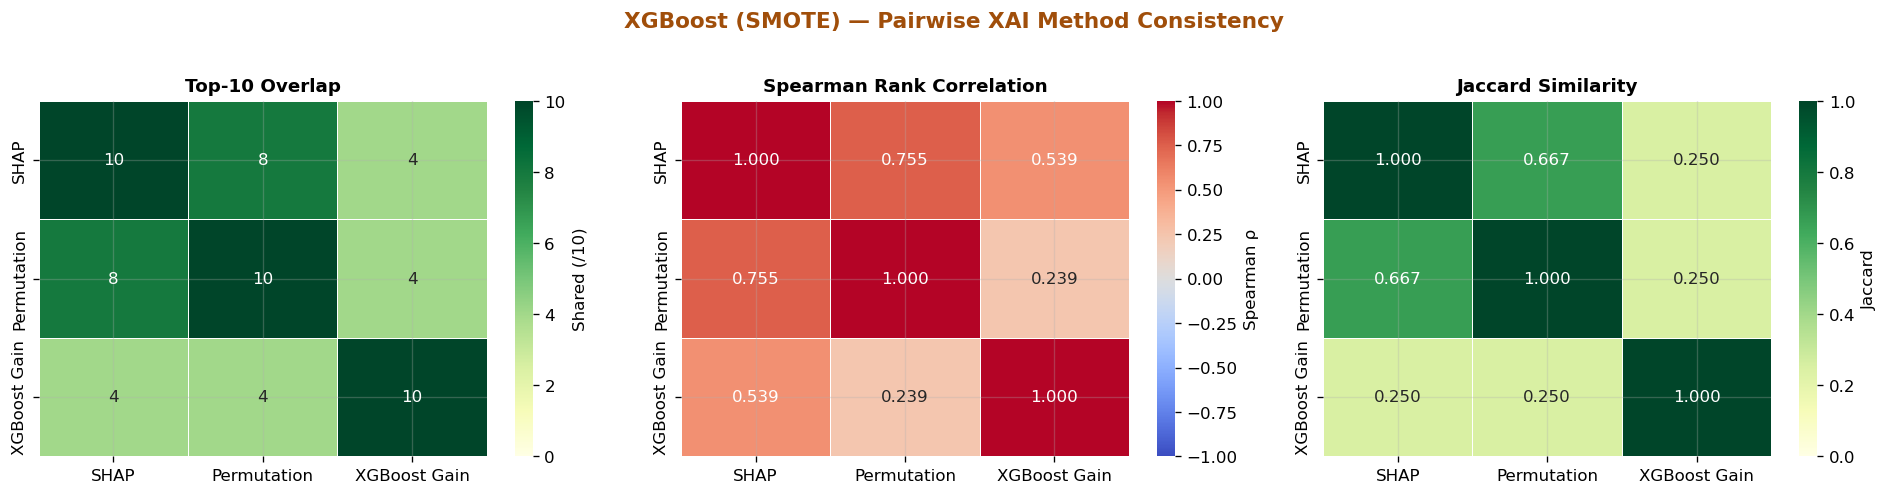

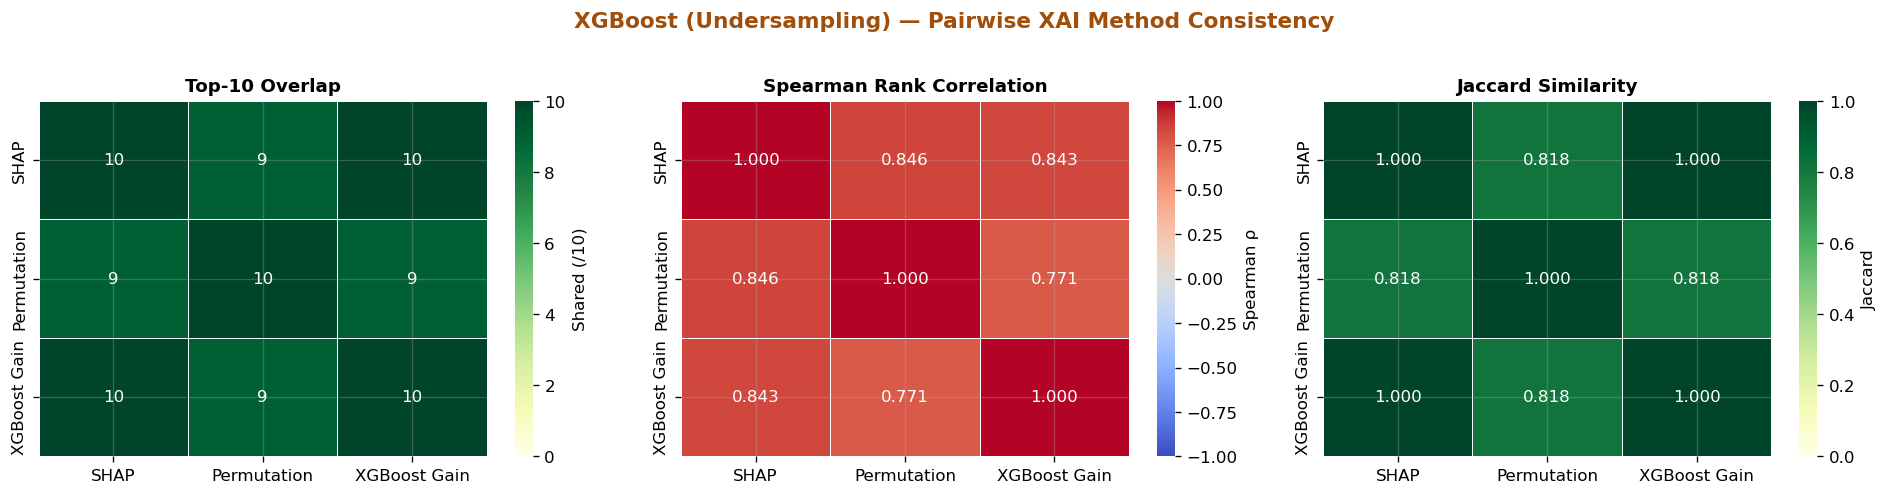

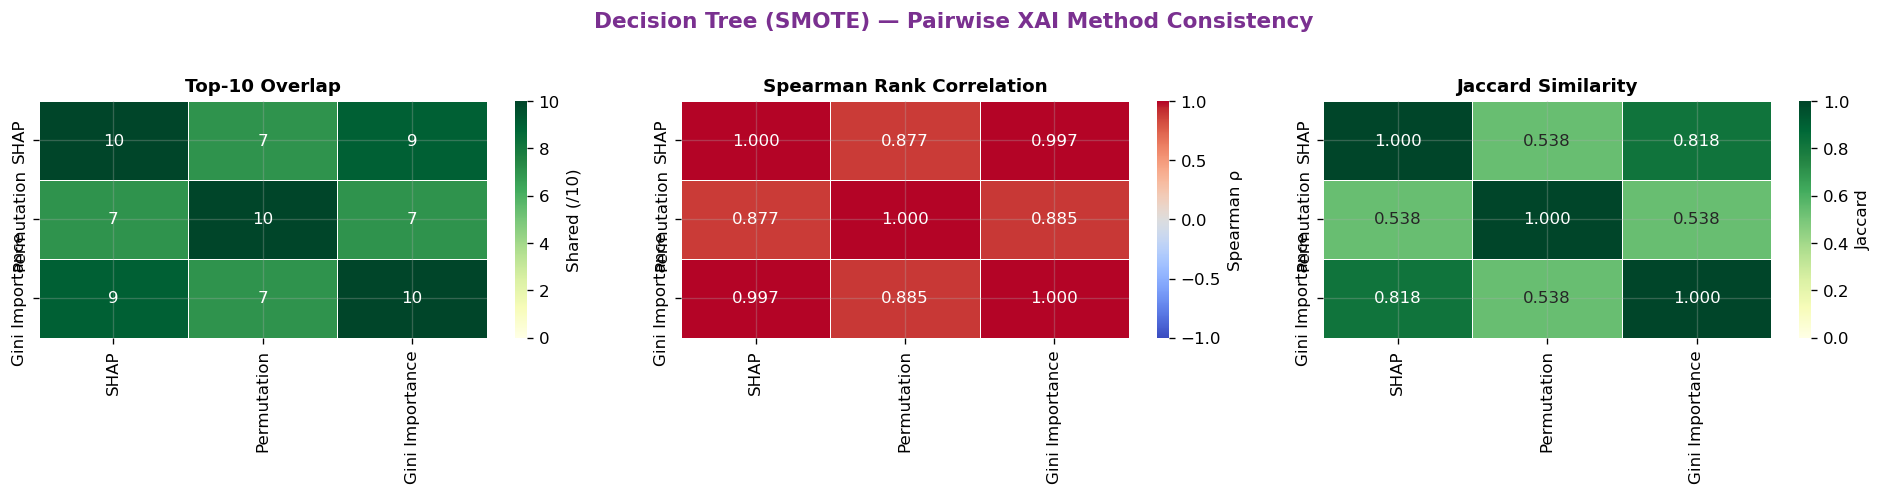

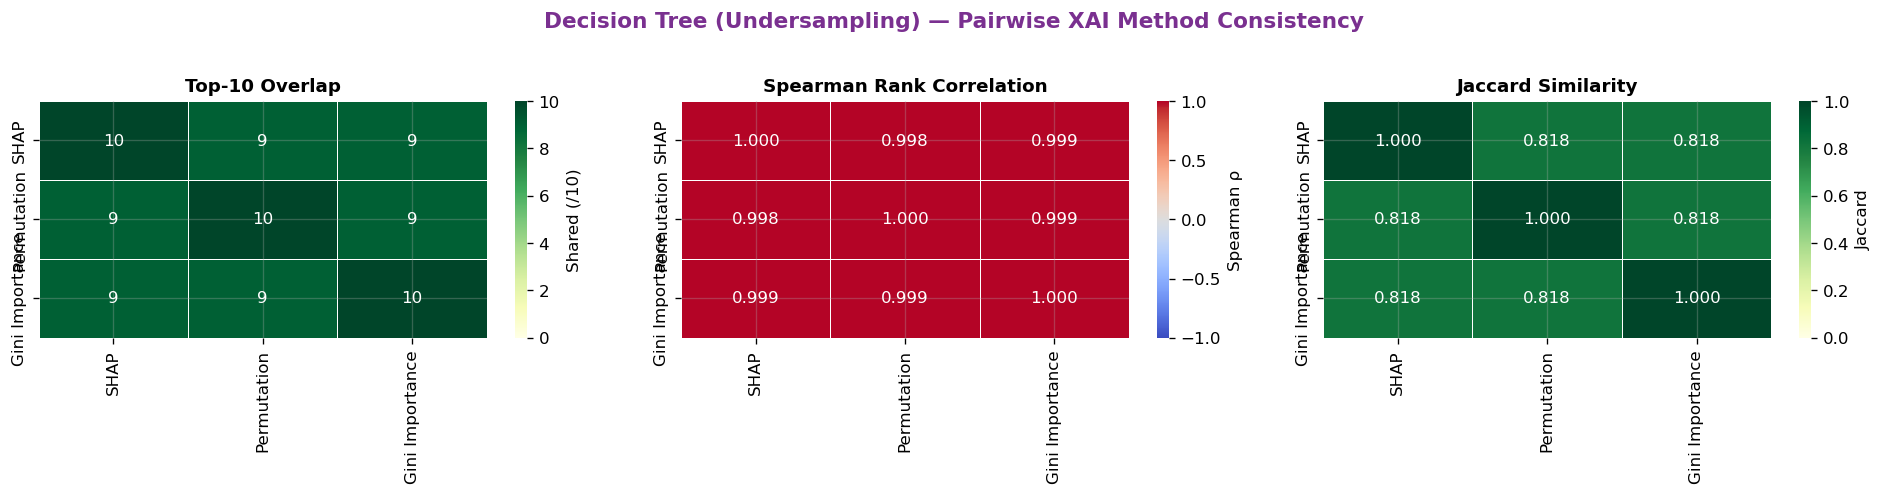

In [5]:
for model in MODELS:
    for strategy in STRATEGIES:
        overlap_mat   = build_method_matrix(df, model, strategy, top_n_overlap)
        spearman_mat  = build_method_matrix(df, model, strategy, spearman_correlation)
        jaccard_mat   = build_method_matrix(df, model, strategy, jaccard_similarity)

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # --- Top-10 Overlap ---
        sns.heatmap(
            overlap_mat.astype(float),
            annot=True, fmt=".0f", cmap="YlGn",
            vmin=0, vmax=TOP_N,
            linewidths=0.5, linecolor="white",
            ax=axes[0],
            cbar_kws={"label": f"Shared (/{TOP_N})"}
        )
        axes[0].set_title(f"Top-{TOP_N} Overlap", fontsize=11, fontweight="bold")

        # --- Spearman ρ ---
        sns.heatmap(
            spearman_mat.astype(float),
            annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor="white",
            ax=axes[1],
            cbar_kws={"label": "Spearman ρ"}
        )
        axes[1].set_title("Spearman Rank Correlation", fontsize=11, fontweight="bold")

        # --- Jaccard ---
        sns.heatmap(
            jaccard_mat.astype(float),
            annot=True, fmt=".3f", cmap="YlGn",
            vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            ax=axes[2],
            cbar_kws={"label": "Jaccard"}
        )
        axes[2].set_title("Jaccard Similarity", fontsize=11, fontweight="bold")

        fig.suptitle(
            f"{model} ({strategy}) — Pairwise XAI Method Consistency",
            fontsize=13, fontweight="bold",
            color=MODEL_COLORS[model], y=1.02
        )
        plt.tight_layout()

        safe_model    = model.lower().replace(" ", "_")
        safe_strategy = strategy.lower()
        plt.savefig(
            f"../results/figures/xai_method_consistency/{safe_model}_{safe_strategy}_heatmaps.png",
            bbox_inches="tight"
        )
        plt.show()
        print()

---
# Section 3 — Spearman ρ Overview: All Model × Strategy × Method-Pair Combinations

A single heatmap collecting all Spearman ρ values across every Model × Strategy combination and the three method pairs. Rows are `Model (Strategy)`, columns are the three XAI method pairs.

This gives a panoramic view of where XAI methods agree and where they diverge — across the entire experiment.

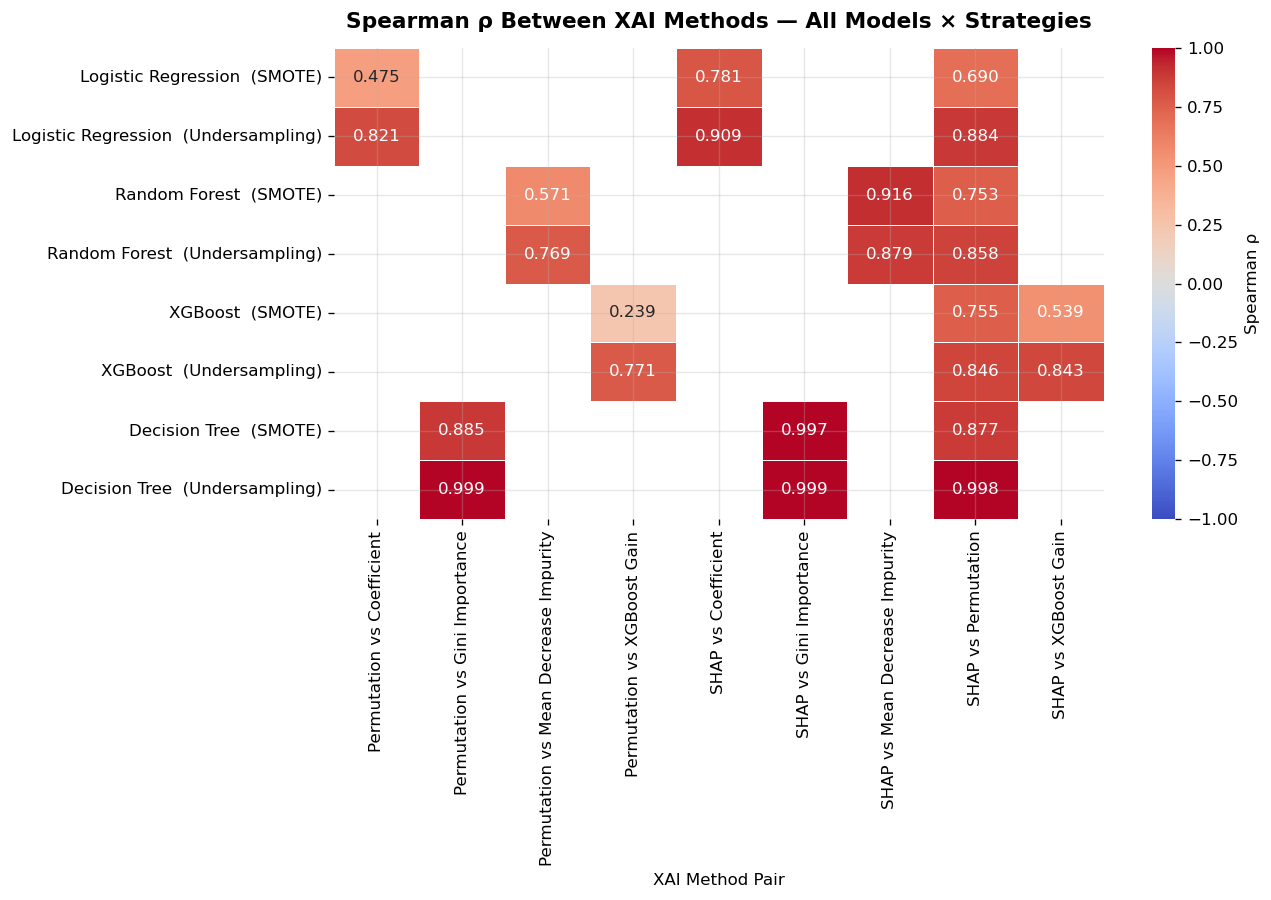

Overall mean Spearman ρ across all pairs: 0.794
Pair-level means:
Pair
Permutation vs Coefficient               0.648
Permutation vs Gini Importance           0.942
Permutation vs Mean Decrease Impurity    0.670
Permutation vs XGBoost Gain              0.505
SHAP vs Coefficient                      0.845
SHAP vs Gini Importance                  0.998
SHAP vs Mean Decrease Impurity           0.898
SHAP vs Permutation                      0.833
SHAP vs XGBoost Gain                     0.691


In [6]:
summary_df = compute_pairwise_summary(df)

# Build pivot: rows = Model (Strategy), columns = Method A vs Method B
summary_df["Pair"]    = summary_df["Method A"] + " vs " + summary_df["Method B"]
summary_df["Row Label"] = summary_df["Model"] + "  (" + summary_df["Strategy"] + ")"

spearman_pivot = summary_df.pivot_table(
    index="Row Label", columns="Pair", values="Spearman ρ"
)

# Sort rows by model order
row_order = [
    f"{m}  ({s})" for m in MODELS for s in STRATEGIES
    if f"{m}  ({s})" in spearman_pivot.index
]
spearman_pivot = spearman_pivot.loc[row_order]

fig, ax = plt.subplots(figsize=(11, len(row_order) * 0.7 + 2))
sns.heatmap(
    spearman_pivot.astype(float),
    annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"label": "Spearman ρ"}
)
ax.set_title(
    "Spearman ρ Between XAI Methods — All Models × Strategies",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("XAI Method Pair", fontsize=10)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../results/figures/xai_method_consistency/spearman_overview_heatmap.png", bbox_inches="tight")
plt.show()

print(f"Overall mean Spearman ρ across all pairs: {summary_df['Spearman ρ'].mean():.3f}")
print(f"Pair-level means:")
print(summary_df.groupby("Pair")["Spearman ρ"].mean().round(3).to_string())

---
# Section 4 — Top-10 Overlap Overview (All Pairs)

The same panoramic view as Section 3, now for **Top-10 overlap** counts. Each cell shows how many of the top 10 features are shared between the two XAI methods for that Model × Strategy.

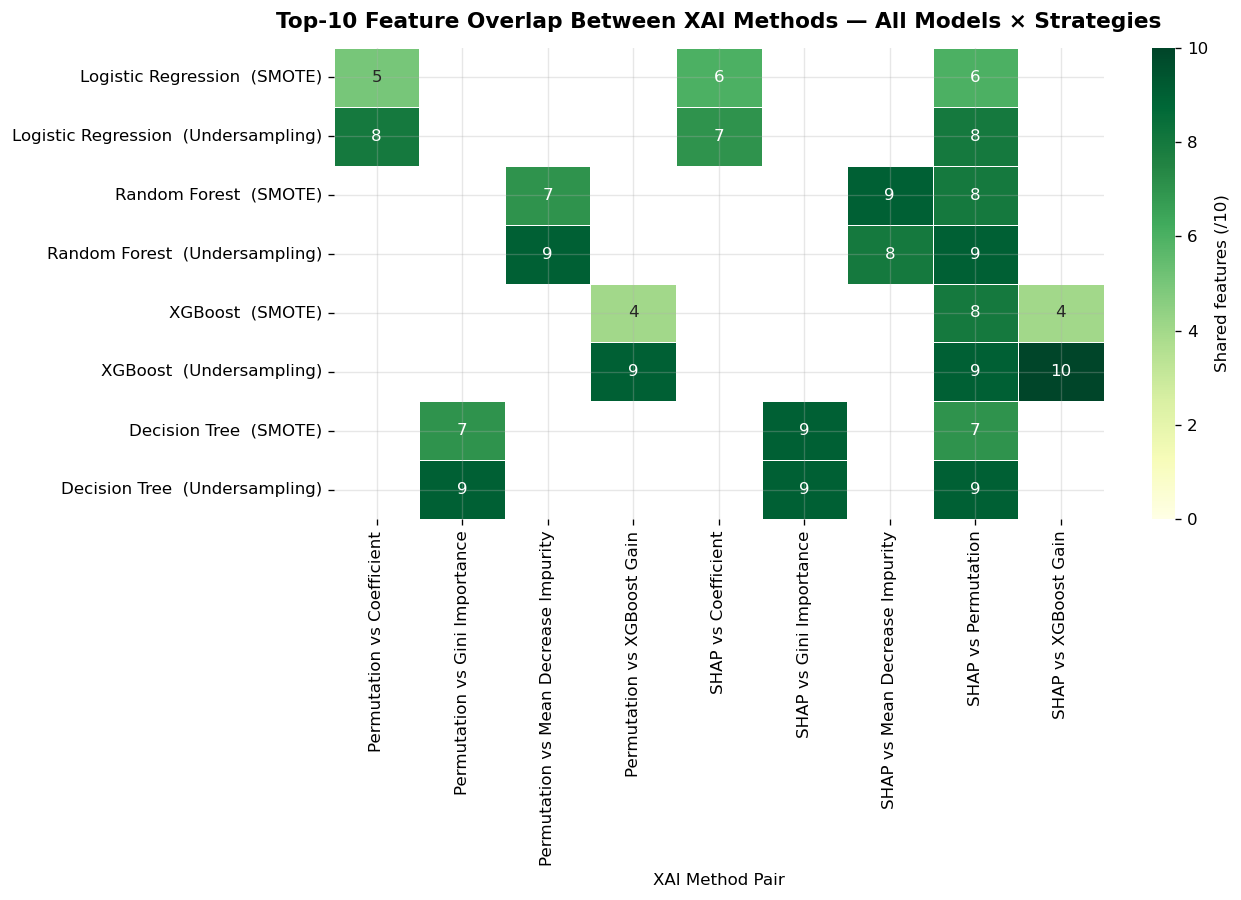

Overall mean Top-10 overlap: 7.67
Pair-level means:
Pair
Permutation vs Coefficient               6.5
Permutation vs Gini Importance           8.0
Permutation vs Mean Decrease Impurity    8.0
Permutation vs XGBoost Gain              6.5
SHAP vs Coefficient                      6.5
SHAP vs Gini Importance                  9.0
SHAP vs Mean Decrease Impurity           8.5
SHAP vs Permutation                      8.0
SHAP vs XGBoost Gain                     7.0


In [7]:
overlap_pivot = summary_df.pivot_table(
    index="Row Label", columns="Pair", values="Top-N Overlap"
).loc[row_order]

fig, ax = plt.subplots(figsize=(11, len(row_order) * 0.7 + 2))
sns.heatmap(
    overlap_pivot.astype(float),
    annot=True, fmt=".0f", cmap="YlGn",
    vmin=0, vmax=TOP_N,
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"label": f"Shared features (/{TOP_N})"}
)
ax.set_title(
    f"Top-{TOP_N} Feature Overlap Between XAI Methods — All Models × Strategies",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("XAI Method Pair", fontsize=10)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../results/figures/xai_method_consistency/overlap_overview_heatmap.png", bbox_inches="tight")
plt.show()

print(f"Overall mean Top-{TOP_N} overlap: {summary_df['Top-N Overlap'].mean():.2f}")
print(f"Pair-level means:")
print(summary_df.groupby("Pair")["Top-N Overlap"].mean().round(2).to_string())

---
# Section 5 — Jaccard Similarity Overview (All Pairs)

Jaccard similarity panoramic view, normalised to [0, 1]. Complements the overlap count from Section 4 by accounting for the full union of both top-10 sets.

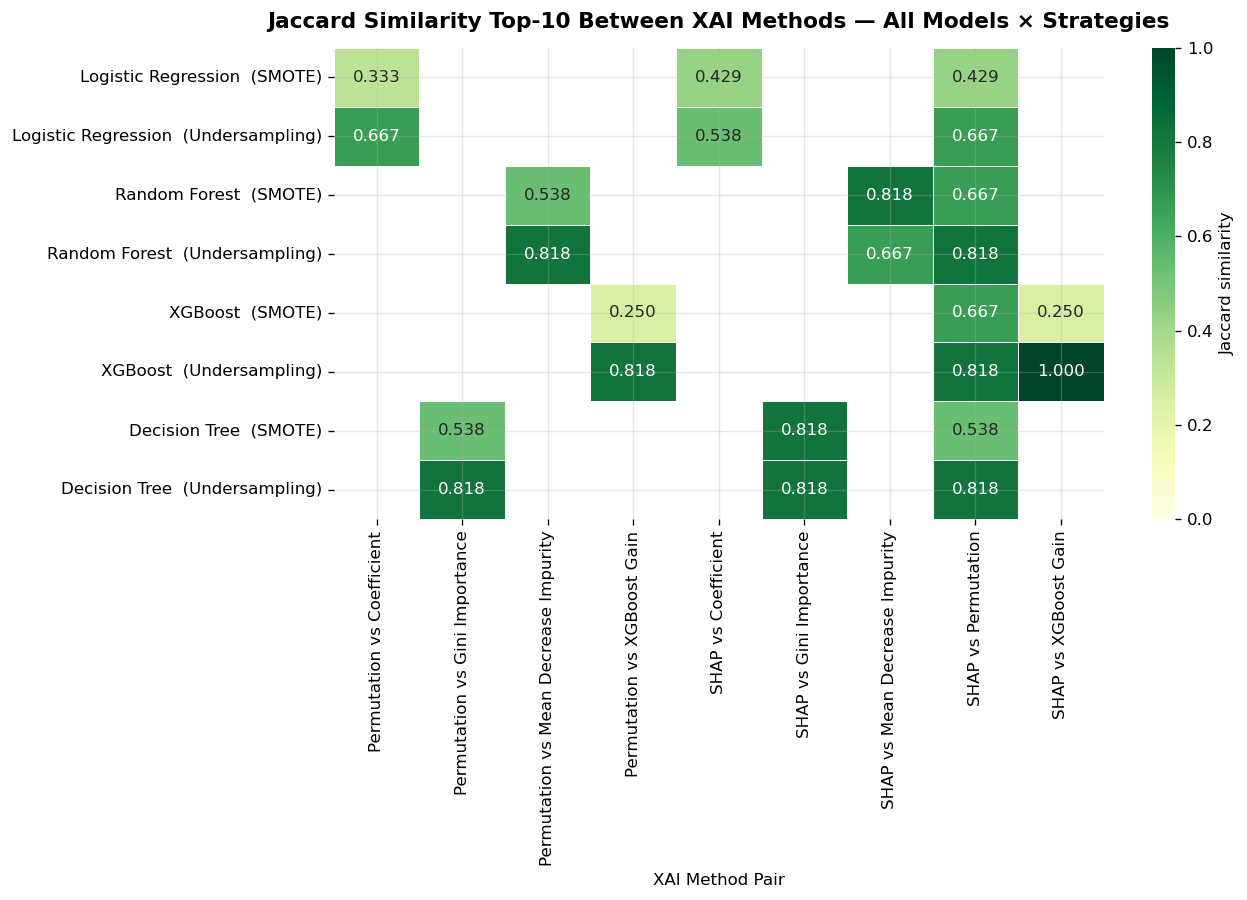

Overall mean Jaccard similarity: 0.648
Pair-level means:
Pair
Permutation vs Coefficient               0.500
Permutation vs Gini Importance           0.678
Permutation vs Mean Decrease Impurity    0.678
Permutation vs XGBoost Gain              0.534
SHAP vs Coefficient                      0.484
SHAP vs Gini Importance                  0.818
SHAP vs Mean Decrease Impurity           0.742
SHAP vs Permutation                      0.678
SHAP vs XGBoost Gain                     0.625


In [8]:
jaccard_pivot = summary_df.pivot_table(
    index="Row Label", columns="Pair", values="Jaccard Similarity"
).loc[row_order]

fig, ax = plt.subplots(figsize=(11, len(row_order) * 0.7 + 2))
sns.heatmap(
    jaccard_pivot.astype(float),
    annot=True, fmt=".3f", cmap="YlGn",
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"label": "Jaccard similarity"}
)
ax.set_title(
    f"Jaccard Similarity Top-{TOP_N} Between XAI Methods — All Models × Strategies",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("XAI Method Pair", fontsize=10)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../results/figures/xai_method_consistency/jaccard_overview_heatmap.png", bbox_inches="tight")
plt.show()

print(f"Overall mean Jaccard similarity: {summary_df['Jaccard Similarity'].mean():.3f}")
print(f"Pair-level means:")
print(summary_df.groupby("Pair")["Jaccard Similarity"].mean().round(3).to_string())

---
# Section 6 — Rank Shift Analysis: SHAP vs Model-Specific Method

The model-specific method (coefficients, impurity, gain) is trained-in and fast to compute, while SHAP is model-agnostic and computationally heavier. A common question is whether they tell the same story.

For each model × strategy, the rank change of every feature between SHAP and the model-specific method is shown. A large rank shift means the two methods disagree strongly on that feature's importance.

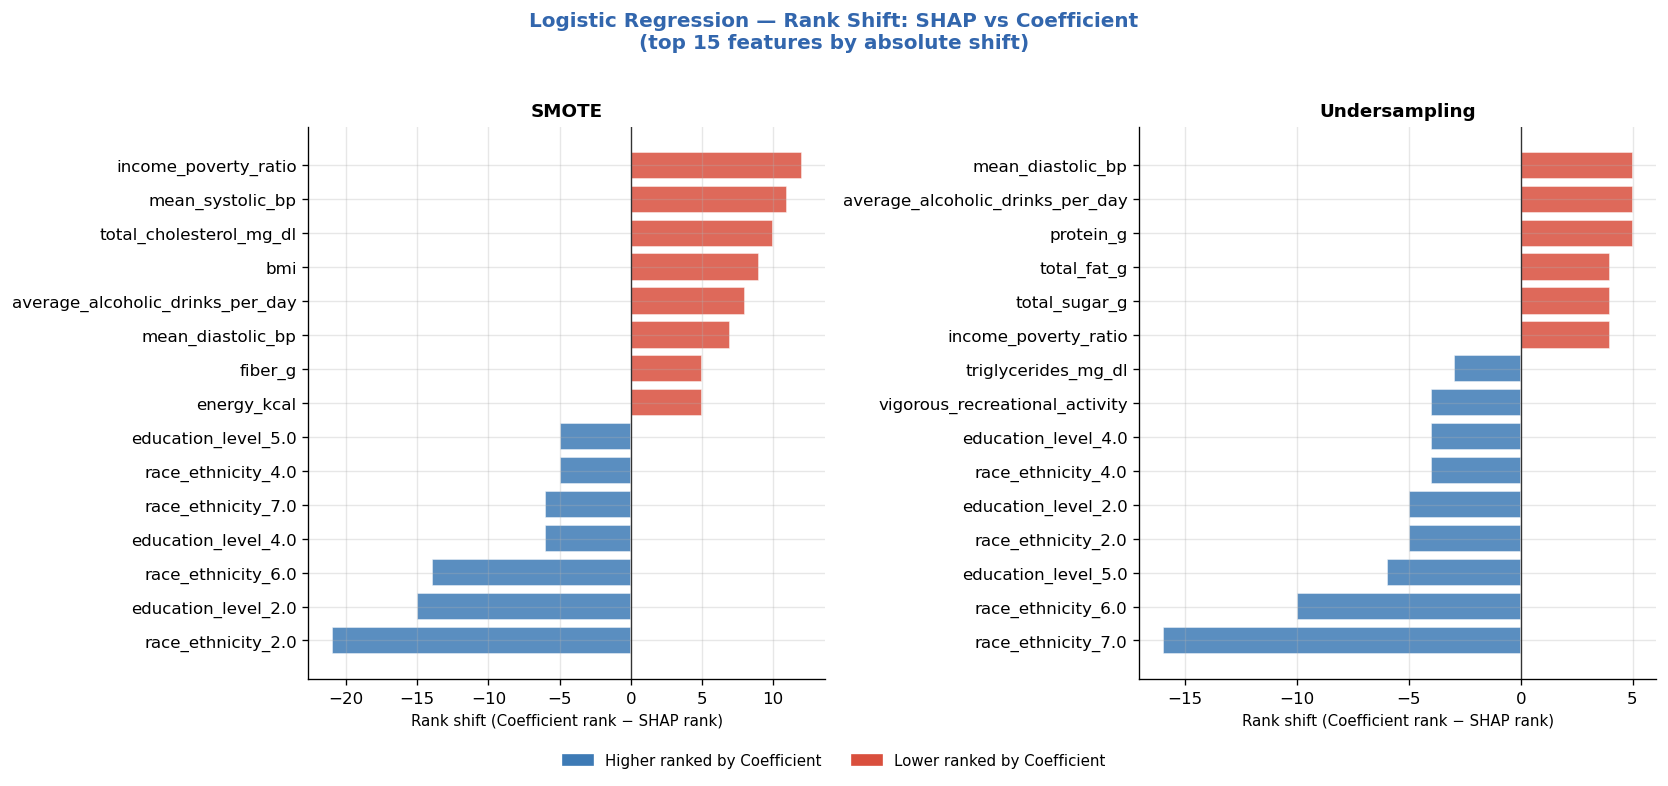

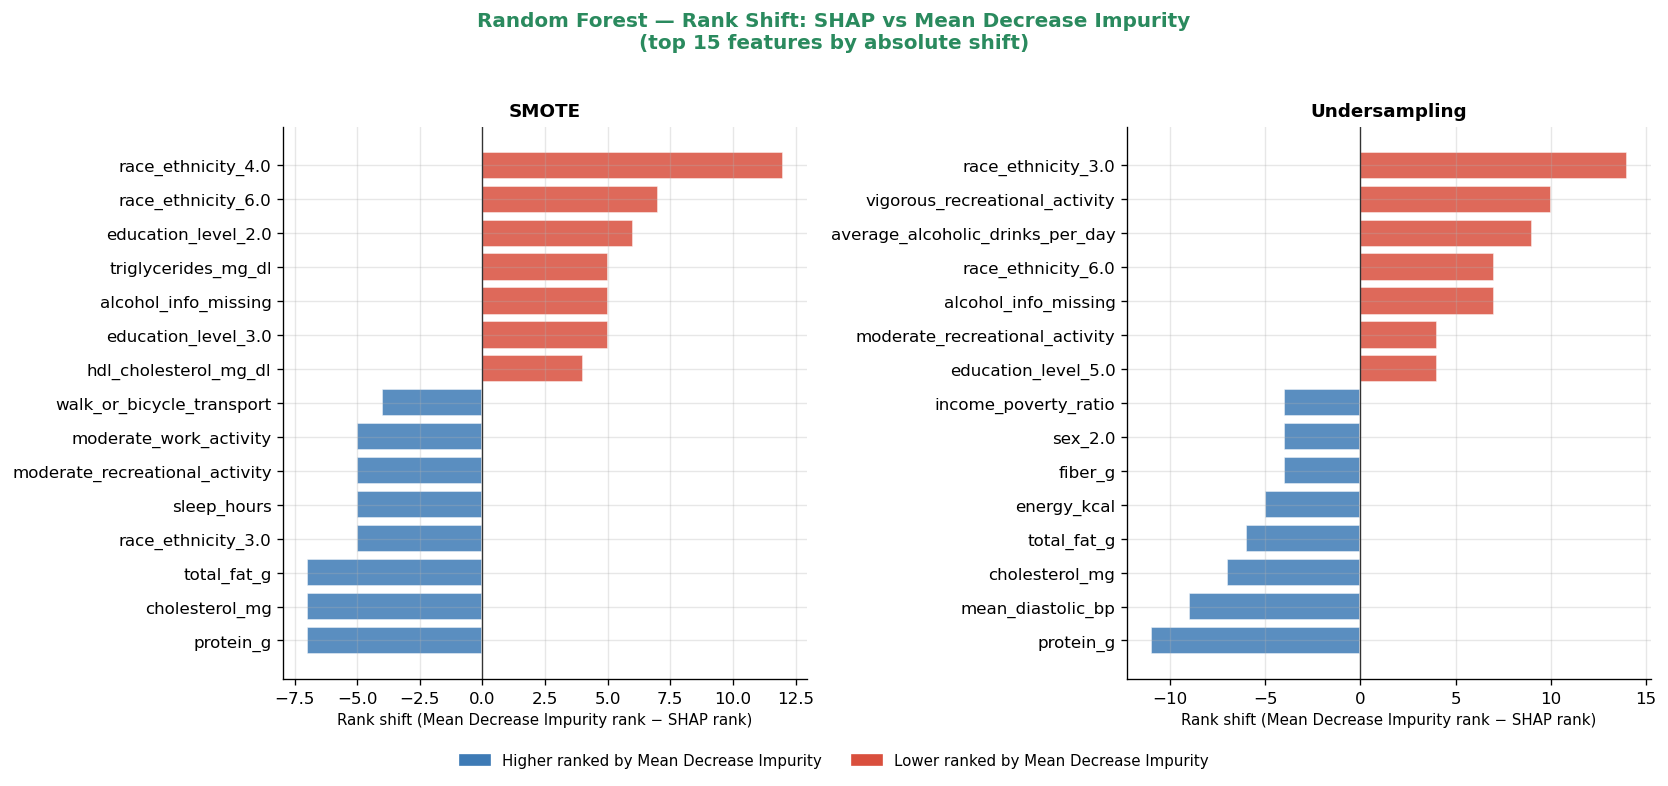

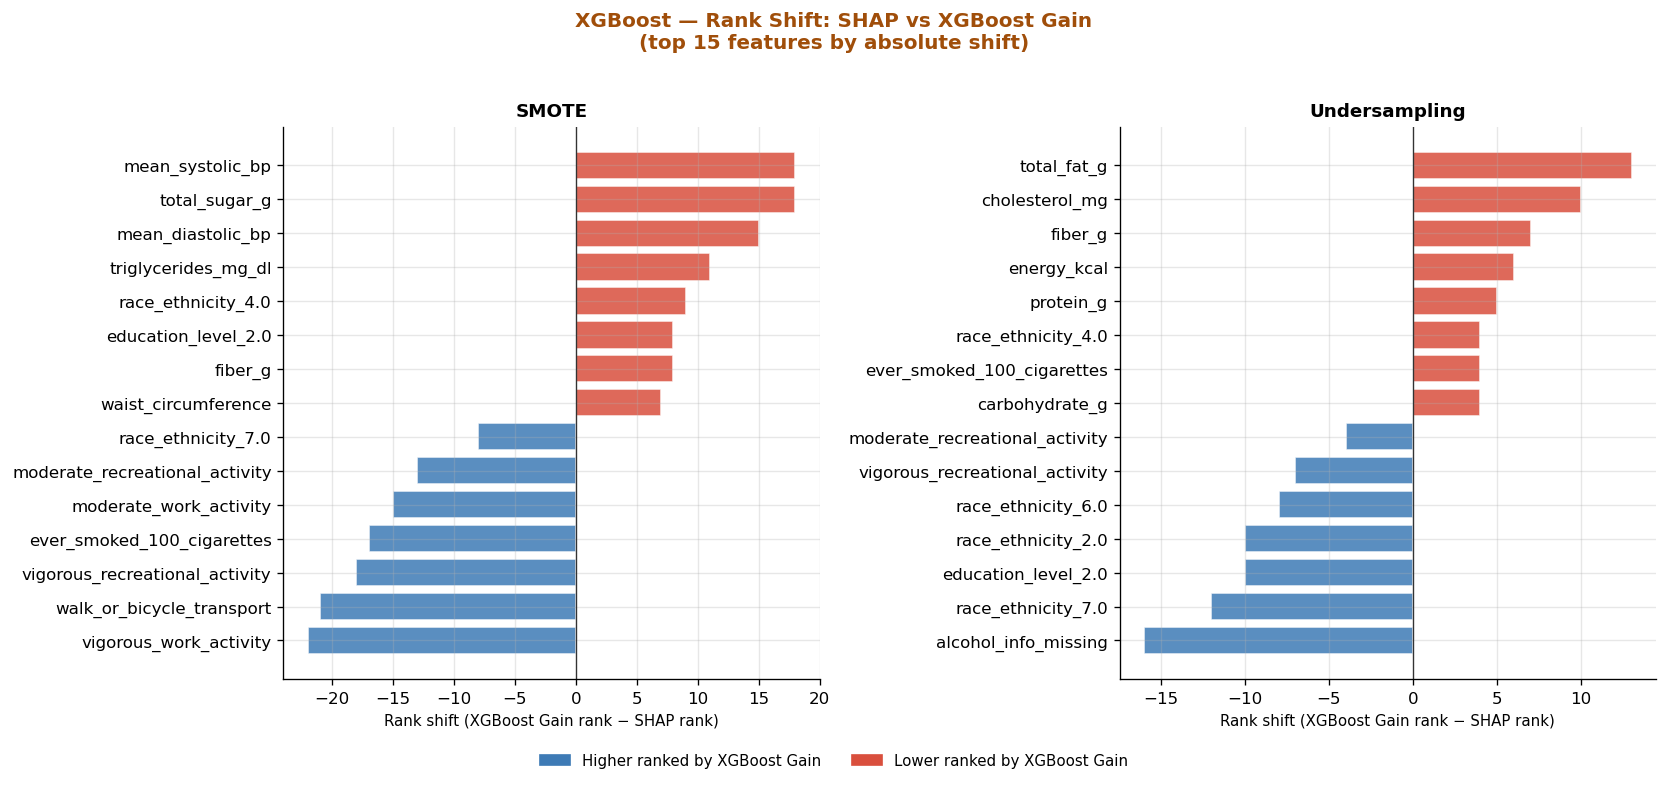

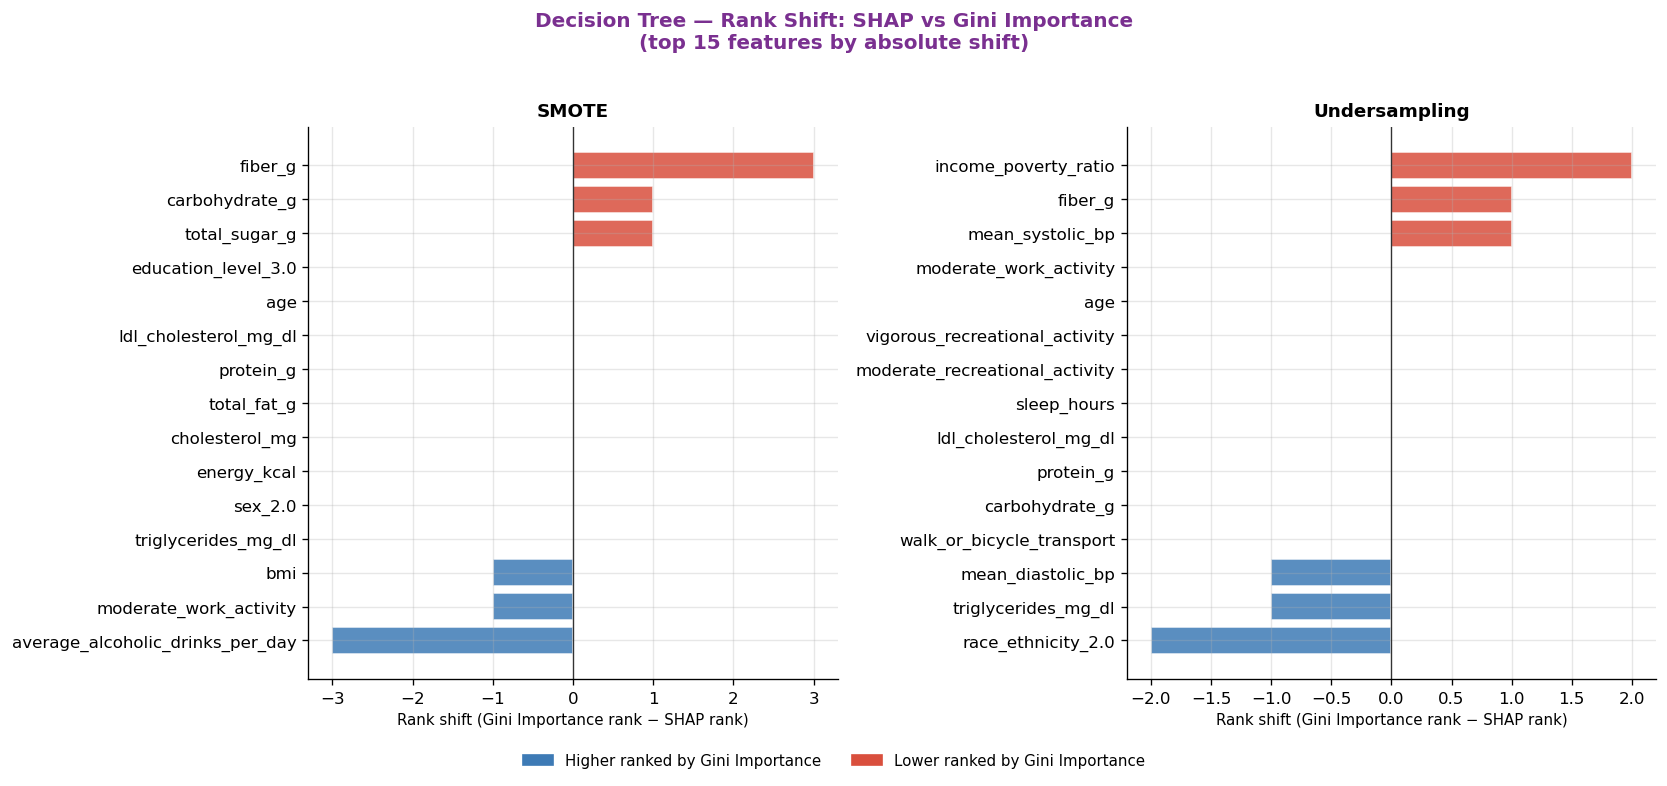

In [9]:
for model in MODELS:
    specific_label = MODEL_SPECIFIC_METHOD[model]
    color = MODEL_COLORS[model]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, strategy in zip(axes, STRATEGIES):
        rank_shap = get_full_ranking(df, model, strategy, "SHAP").rename("Rank_SHAP")
        rank_spec = get_full_ranking(df, model, strategy, "Specific").rename("Rank_Specific")

        if rank_shap.empty or rank_spec.empty:
            ax.set_title(f"{strategy}\n(no data)", fontsize=10)
            ax.axis("off")
            continue

        merged = pd.concat([rank_shap, rank_spec], axis=1).dropna()
        merged["Rank Shift"] = merged["Rank_Specific"] - merged["Rank_SHAP"]
        merged["Abs Shift"]  = merged["Rank Shift"].abs()
        top15 = merged.sort_values("Abs Shift", ascending=False).head(15)
        top15 = top15.sort_values("Rank Shift")

        bar_colors = ["#d94f3d" if v > 0 else "#3d7ab5" for v in top15["Rank Shift"]]
        ax.barh(top15.index, top15["Rank Shift"],
                color=bar_colors, edgecolor="white", alpha=0.85)
        ax.axvline(x=0, color="#333", linewidth=0.8)
        ax.set_xlabel(f"Rank shift ({specific_label} rank − SHAP rank)", fontsize=9)
        ax.set_title(strategy, fontsize=11, fontweight="bold")

    neg_patch = mpatches.Patch(color="#3d7ab5", label=f"Higher ranked by {specific_label}")
    pos_patch = mpatches.Patch(color="#d94f3d", label=f"Lower ranked by {specific_label}")
    fig.legend(handles=[neg_patch, pos_patch], loc="lower center", ncol=2,
               fontsize=9, bbox_to_anchor=(0.5, -0.05), frameon=False)

    fig.suptitle(
        f"{model} — Rank Shift: SHAP vs {specific_label}\n(top 15 features by absolute shift)",
        fontsize=12, fontweight="bold", color=color, y=1.02
    )
    plt.tight_layout()

    safe_model = model.lower().replace(" ", "_")
    plt.savefig(
        f"../results/figures/xai_method_consistency/{safe_model}_shap_vs_specific_rank_shift.png",
        bbox_inches="tight"
    )
    plt.show()
    print()

---
# Section 7 — Summary Table

A complete summary of all pairwise XAI method consistency scores across every Model × Strategy combination, sorted by Spearman ρ (descending).

In [10]:
display_df = summary_df[[
    "Model", "Strategy", "Method A", "Method B",
    "Top-N Overlap", "Spearman ρ", "Jaccard Similarity"
]].copy().sort_values("Spearman ρ", ascending=False).reset_index(drop=True)

display_df["Top-N Overlap"] = display_df["Top-N Overlap"].apply(
    lambda x: f"{int(x)}/{TOP_N}"
)

print(f"XAI Method Consistency Summary — Top-{TOP_N}, all Model × Strategy combinations")
print("=" * 85)
display(display_df)

print()
print("Grand means across all Model × Strategy × Pair combinations:")
raw = summary_df.copy()
print(f"  Spearman ρ:         {raw['Spearman ρ'].mean():.3f}")
print(f"  Jaccard Similarity: {raw['Jaccard Similarity'].mean():.3f}")
print(f"  Top-N Overlap:      {raw['Top-N Overlap'].mean():.1f} / {TOP_N}")

print()
print("Mean Spearman ρ per method pair (averaged over all Model × Strategy):")
print(raw.groupby("Pair")["Spearman ρ"].agg(["mean", "min", "max"]).round(3).to_string())

XAI Method Consistency Summary — Top-10, all Model × Strategy combinations


,Model,Strategy,Method A,Method B,Top-N Overlap,Spearman ρ,Jaccard Similarity
0,Decision Tree,Undersampling,Permutation,Gini Importance,9/10,0.9990,0.8182
1,Decision Tree,Undersampling,SHAP,Gini Importance,9/10,0.9985,0.8182
2,Decision Tree,Undersampling,SHAP,Permutation,9/10,0.9982,0.8182
3,Decision Tree,SMOTE,SHAP,Gini Importance,9/10,0.9972,0.8182
4,Random Forest,SMOTE,SHAP,Mean Decrease Impurity,9/10,0.9163,0.8182
5,Logistic Regression,Undersampling,SHAP,Coefficient,7/10,0.9086,0.5385
6,Decision Tree,SMOTE,Permutation,Gini Importance,7/10,0.8847,0.5385
7,Logistic Regression,Undersampling,SHAP,Permutation,8/10,0.8837,0.6667
8,Random Forest,Undersampling,SHAP,Mean Decrease Impurity,8/10,0.8793,0.6667
9,Decision Tree,SMOTE,SHAP,Permutation,7/10,0.8775,0.5385



Grand means across all Model × Strategy × Pair combinations:
  Spearman ρ:         0.794
  Jaccard Similarity: 0.648
  Top-N Overlap:      7.7 / 10

Mean Spearman ρ per method pair (averaged over all Model × Strategy):
                                        mean    min    max
Pair                                                      
Permutation vs Coefficient             0.648  0.475  0.821
Permutation vs Gini Importance         0.942  0.885  0.999
Permutation vs Mean Decrease Impurity  0.670  0.571  0.769
Permutation vs XGBoost Gain            0.505  0.239  0.771
SHAP vs Coefficient                    0.845  0.782  0.909
SHAP vs Gini Importance                0.998  0.997  0.998
SHAP vs Mean Decrease Impurity         0.898  0.879  0.916
SHAP vs Permutation                    0.833  0.690  0.998
SHAP vs XGBoost Gain                   0.691  0.539  0.843
